Upload all 7 GRDC daily discharge .txt files


Saving 6122135_Q_Day.Cmd.txt to 6122135_Q_Day.Cmd.txt
Saving 6213800_Q_Day.Cmd.txt to 6213800_Q_Day.Cmd.txt
Saving 6233367_Q_Day.Cmd.txt to 6233367_Q_Day.Cmd.txt
Saving 6337590_Q_Day.Cmd.txt to 6337590_Q_Day.Cmd (1).txt
Saving 6444100_Q_Day.Cmd.txt to 6444100_Q_Day.Cmd.txt
Saving 6457850_Q_Day.Cmd.txt to 6457850_Q_Day.Cmd.txt
Saving 6667500_Q_Day.Cmd.txt to 6667500_Q_Day.Cmd.txt
  Remarde      (France  ):  20794 days | 58 years (1968–2025)
  Tagus        (Spain   ):  27394 days | 76 years (1942–2017)
  Segea        (Sweden  ):  22009 days | 62 years (1964–2025)
  Sieber       (Germany ):  24528 days | 68 years (1950–2017)
  Tisa         (Hungary ):  34056 days | 95 years (1930–2024)
  Warta        (Poland  ):  27022 days | 75 years (1950–2024)
  Çine Çayı    (Turkey  ):   3176 days | 11 years (1977–1987)

── TABLE 1 ──────────────────────────────────────────
GRDC No.     River             Station Country            Climate type  Area (km²) Alt. (m asl)  Record start  Record end  Record

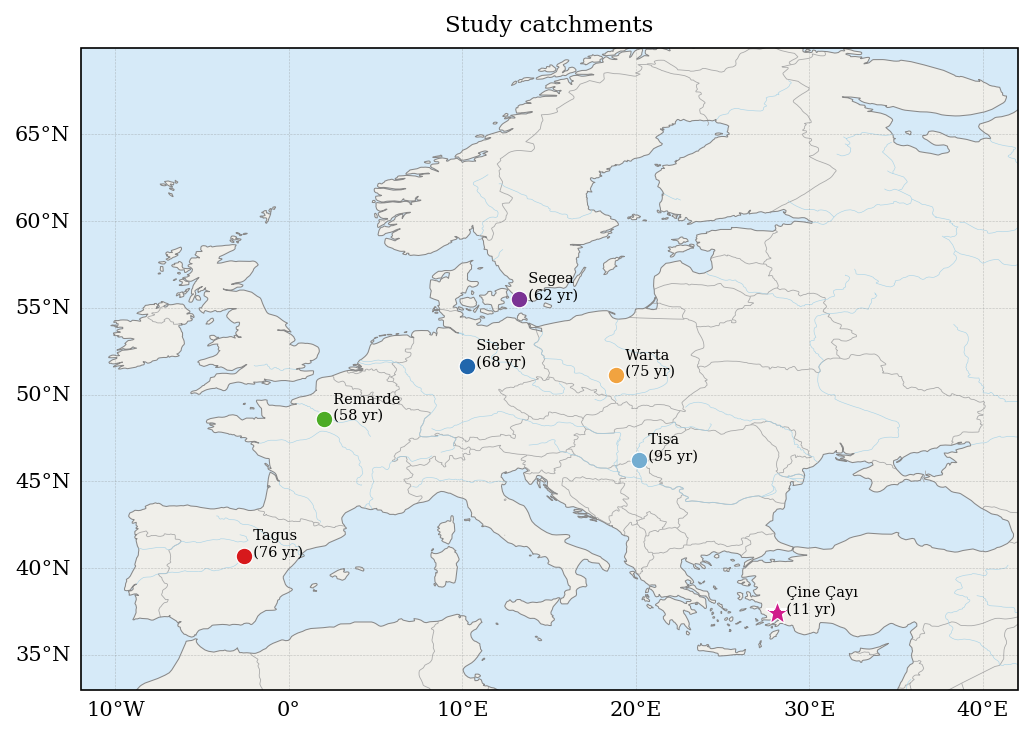

Fig 1 saved.


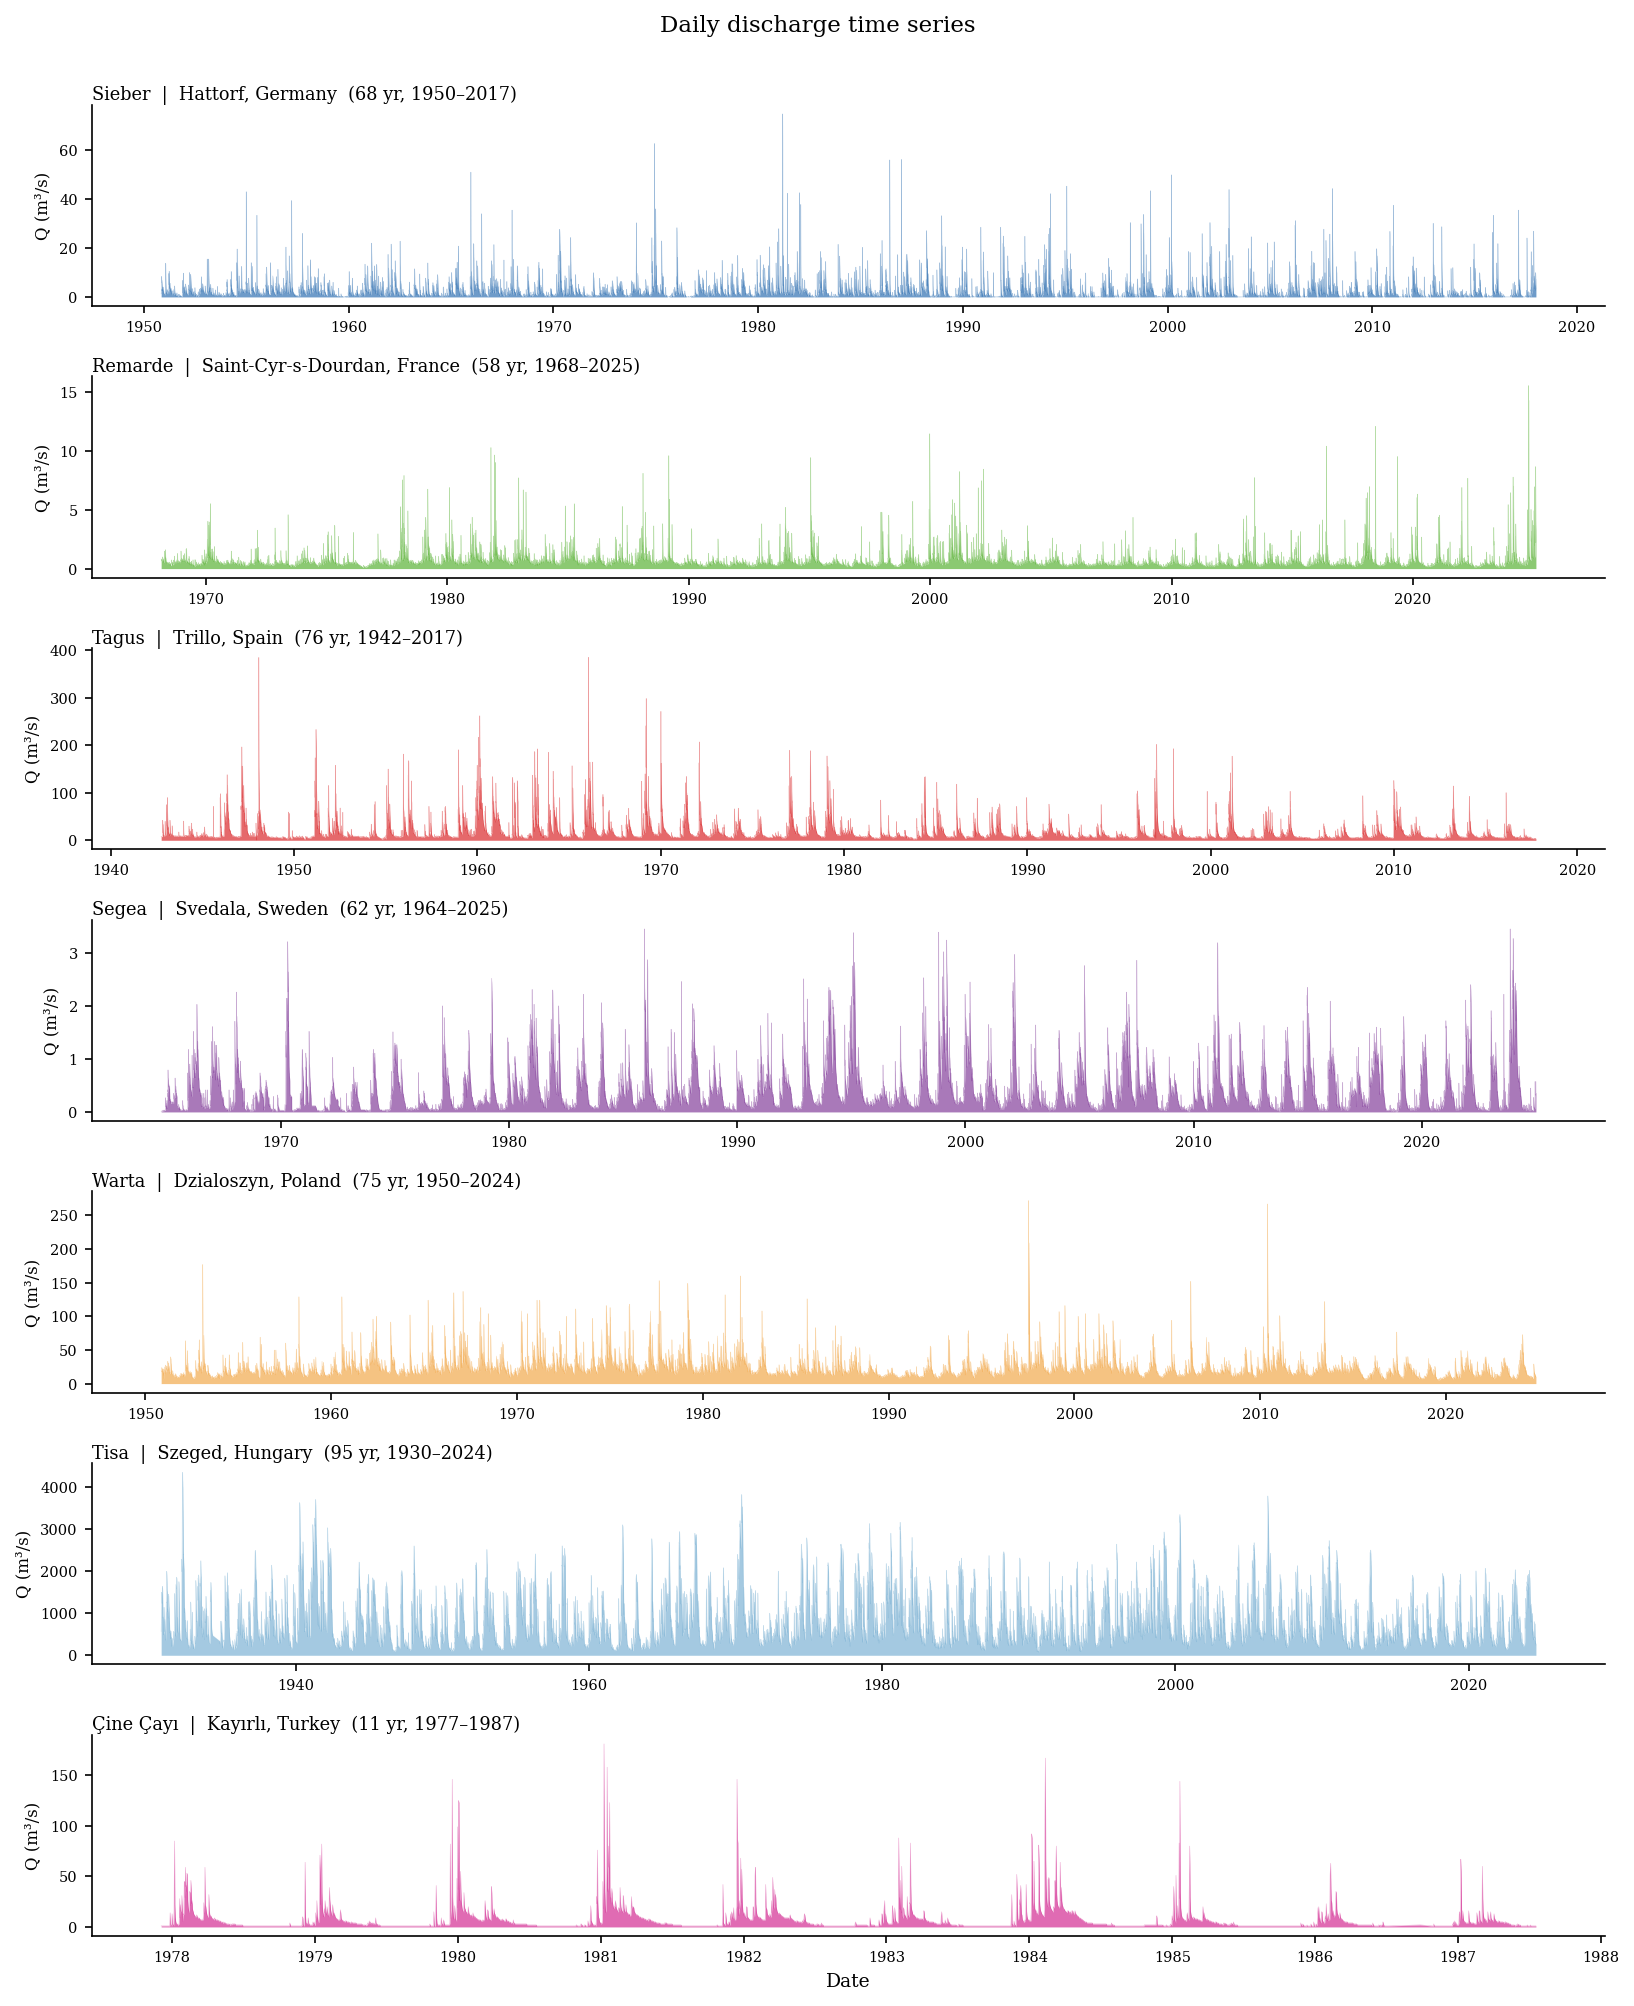

Fig 2 saved.


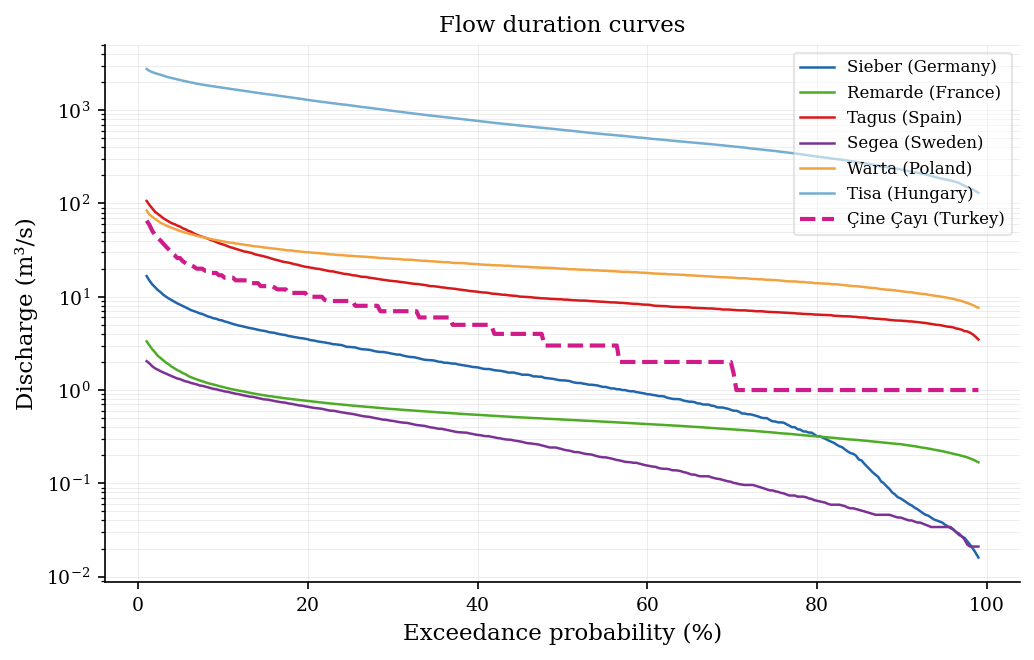

Fig 3 saved.


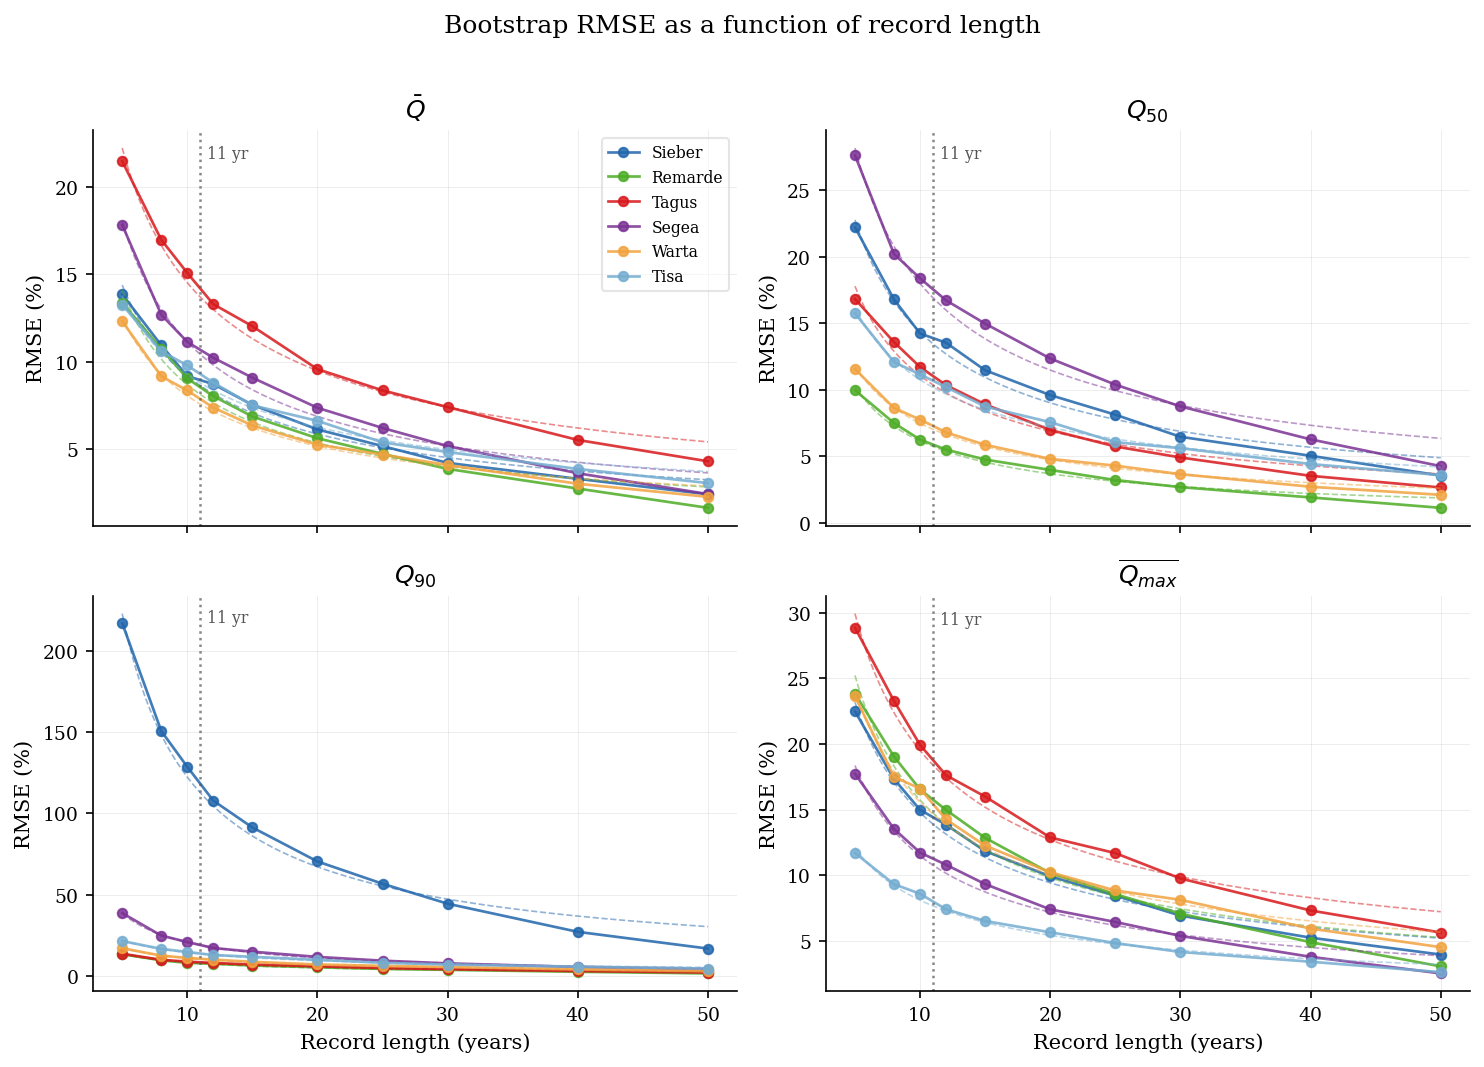

Fig 4 saved.


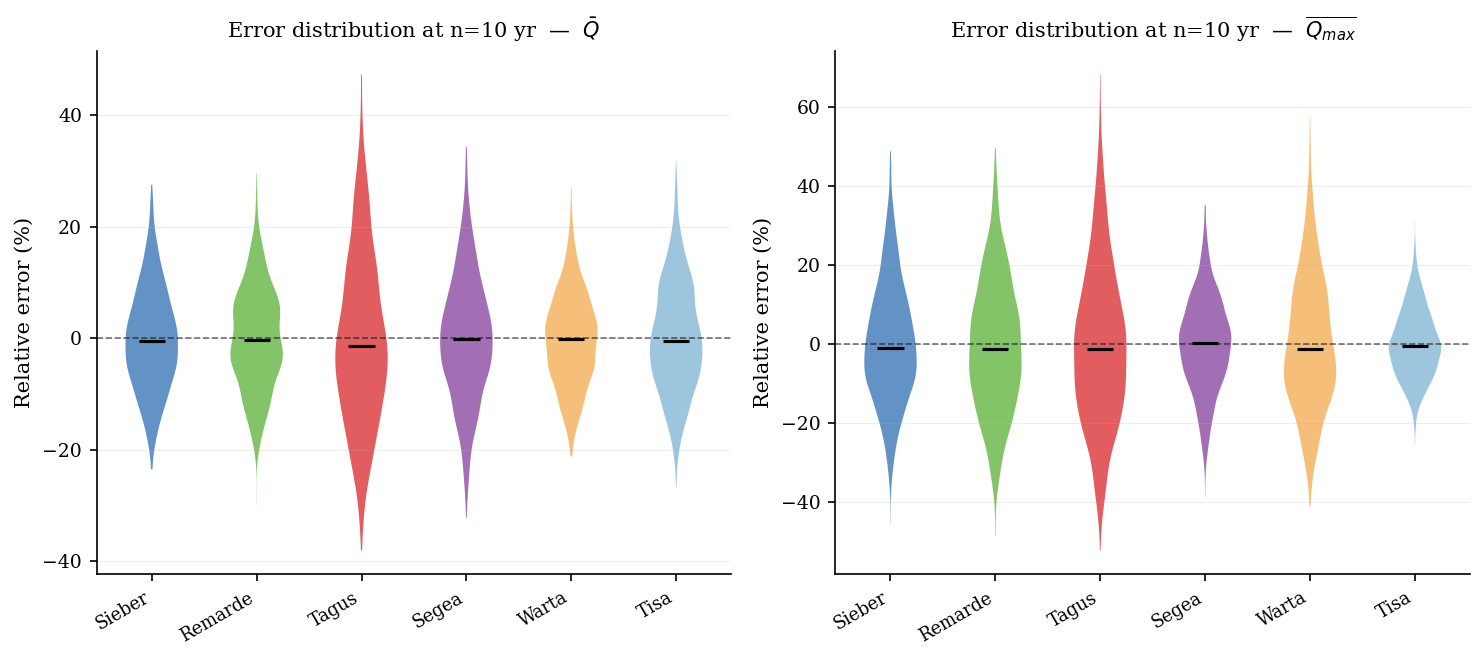

Fig 5 saved.

Power-law (mean):  RMSE = 44.70 · n^(-0.644)
Power-law (upper): RMSE = 59.87 · n^(-0.615)


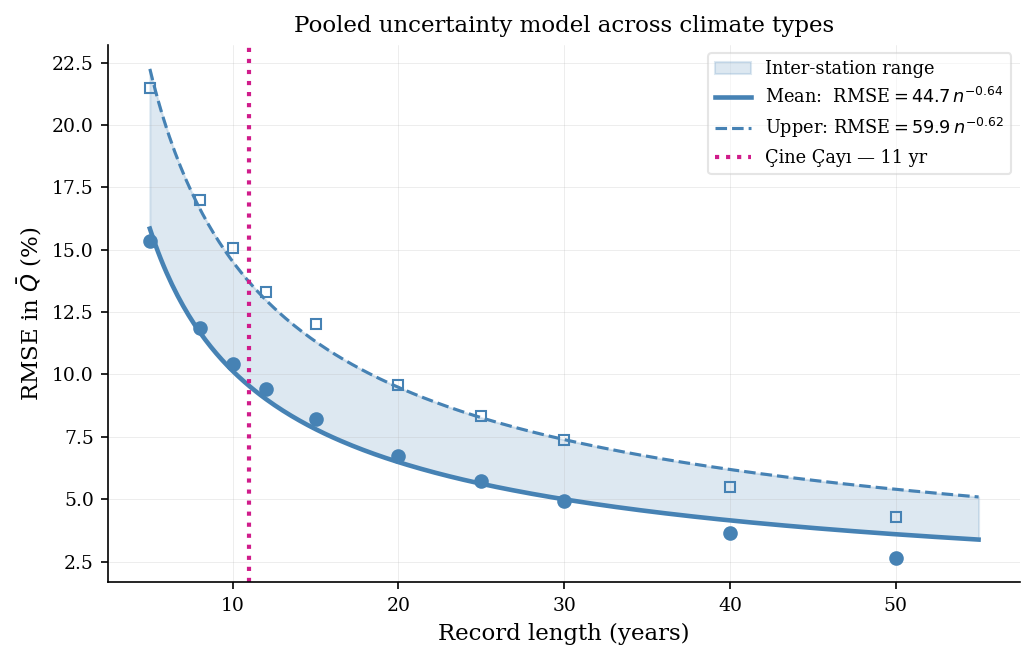

Fig 6 saved.


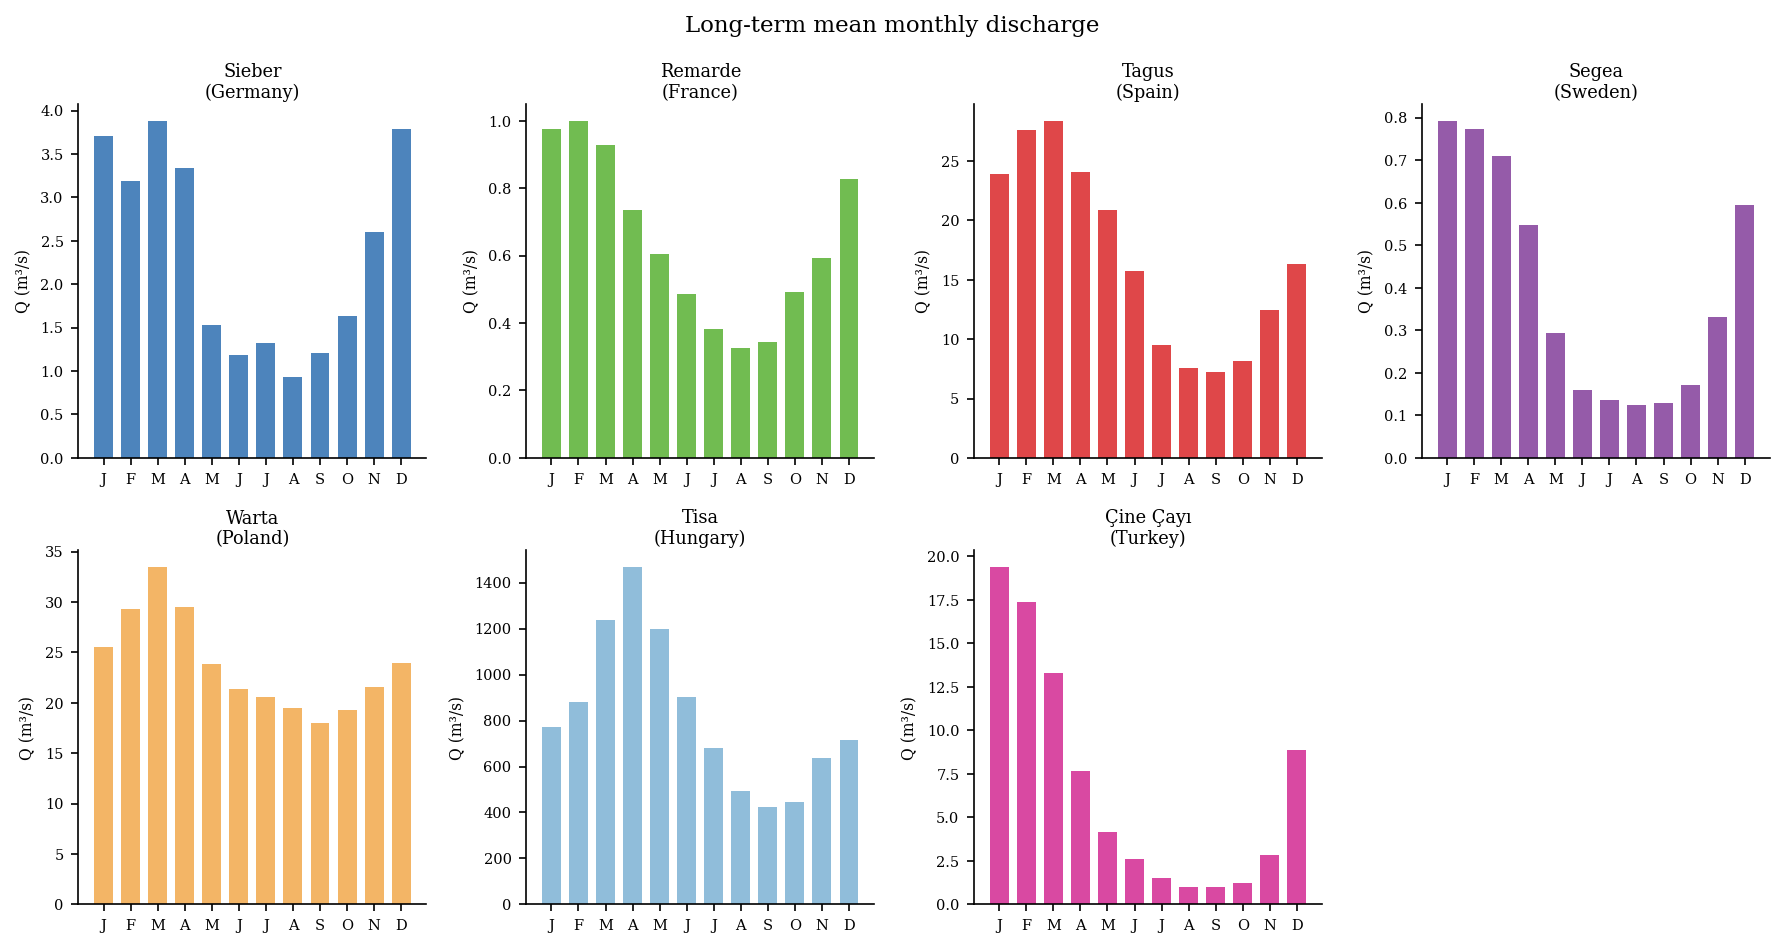

Fig 7 saved.
  added Fig1_map.png
  added Fig2_timeseries.png
  added Fig3_FDC.png
  added Fig4_bootstrap_RMSE.png
  added Fig5_violin.png
  added Fig6_powerlaw.png
  added Fig7_seasonal.png
  added Table1_stations.csv
  added Table2_statistics.csv
  added Table3_bootstrap_rmse.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done — all_outputs.zip downloaded.


In [2]:
# =============================================================================
#  Bootstrap Analysis of Streamflow Record Length
#  "How many years of data are enough?"
#  — Upload your 7 GRDC .txt files when prompted —
# =============================================================================

# ── 0. Dependencies ──────────────────────────────────────────────────────────
!pip install -q cartopy

import io, os, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from google.colab import files

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'       : 'serif',
    'font.size'         : 10,
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 9,
    'figure.dpi'        : 150,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

# ── 1. Station metadata ───────────────────────────────────────────────────────
STATION_META = {
    '6337590': {'river':'Sieber',    'station':'Hattorf',              'country':'Germany',
                'lat':51.651,  'lon':10.255,  'area':127.0,    'alt':184.1,  'climate':'Temperate oceanic'},
    '6122135': {'river':'Remarde',   'station':'Saint-Cyr-s-Dourdan',  'country':'France',
                'lat':48.569,  'lon': 2.033,  'area':147.0,    'alt': 77.2,  'climate':'Temperate oceanic'},
    '6213800': {'river':'Tagus',     'station':'Trillo',               'country':'Spain',
                'lat':40.697,  'lon':-2.586,  'area':3253.0,   'alt':727.0,  'climate':'Mediterranean/semi-arid'},
    '6233367': {'river':'Segea',     'station':'Svedala',              'country':'Sweden',
                'lat':55.507,  'lon':13.238,  'area':52.2,     'alt':None,   'climate':'Boreal'},
    '6457850': {'river':'Warta',     'station':'Dzialoszyn',           'country':'Poland',
                'lat':51.110,  'lon':18.873,  'area':4093.6,   'alt':172.6,  'climate':'Continental'},
    '6444100': {'river':'Tisa',      'station':'Szeged',               'country':'Hungary',
                'lat':46.250,  'lon':20.153,  'area':138408.0, 'alt': 73.7,  'climate':'Continental'},
    '6667500': {'river':'Çine Çayı','station':'Kayırlı',              'country':'Turkey',
                'lat':37.420,  'lon':28.120,  'area':948.0,    'alt':262.0,  'climate':'Mediterranean'},
}

COLORS = {
    '6337590': '#2166ac',  # Germany  – blue
    '6122135': '#4dac26',  # France   – green
    '6213800': '#d7191c',  # Spain    – red
    '6233367': '#7b3294',  # Sweden   – purple
    '6457850': '#f1a340',  # Poland   – orange
    '6444100': '#74add1',  # Hungary  – light-blue
    '6667500': '#d01c8b',  # Turkey   – pink
}

TURKEY_ID  = '6667500'
DISPLAY_ORDER = ['6337590','6122135','6213800','6233367','6457850','6444100','6667500']

# ── 2. File parsing ───────────────────────────────────────────────────────────
def parse_grdc(raw_bytes):
    """Parse a GRDC daily discharge .txt file from raw bytes."""
    text  = raw_bytes.decode('latin-1')
    lines = [l for l in text.split('\n') if not l.startswith('#')]
    df    = pd.read_csv(io.StringIO('\n'.join(lines)), sep=';', skipinitialspace=True)
    df.columns = [c.strip() for c in df.columns]
    # Rename date column
    date_col = [c for c in df.columns if 'YYYY' in c or c.lower().startswith('date')]
    df = df.rename(columns={date_col[0]: 'date'})
    # Pick discharge column (first numeric-looking column that isn't time)
    for c in df.columns:
        if c in ('date',) or 'hh' in c.lower():
            continue
        df['Q'] = pd.to_numeric(df[c], errors='coerce')
        if df['Q'].notna().sum() > 100:
            break
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date','Q'])
    df = df[df['Q'] > 0].sort_values('date').reset_index(drop=True)
    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month
    return df[['date','year','month','Q']]

# ── 3. Upload & load ──────────────────────────────────────────────────────────
print("Upload all 7 GRDC daily discharge .txt files")
uploaded = files.upload()

rivers = {}
for fname, fbytes in uploaded.items():
    sid = fname.split('_')[0]
    df  = parse_grdc(fbytes)
    rivers[sid] = df
    m = STATION_META.get(sid, {})
    print(f"  {m.get('river','?'):12s} ({m.get('country','?'):8s}): "
          f"{len(df):6d} days | {df['year'].nunique()} years "
          f"({df['year'].min()}–{df['year'].max()})")

LONG_IDS = [sid for sid in DISPLAY_ORDER if sid != TURKEY_ID and sid in rivers]

# ── 4. Table 1 — Station characteristics ─────────────────────────────────────
rows = []
for sid in [s for s in DISPLAY_ORDER if s in rivers]:
    m  = STATION_META[sid]
    df = rivers[sid]
    rows.append({
        'GRDC No.'     : sid,
        'River'        : m['river'],
        'Station'      : m['station'],
        'Country'      : m['country'],
        'Climate type' : m['climate'],
        'Area (km²)'   : m['area'],
        'Alt. (m asl)' : m['alt'] if m['alt'] else '—',
        'Record start' : df['year'].min(),
        'Record end'   : df['year'].max(),
        'Record (yr)'  : df['year'].nunique(),
        'N (days)'     : len(df),
    })
T1 = pd.DataFrame(rows)
print("\n── TABLE 1 ──────────────────────────────────────────")
print(T1.to_string(index=False))
T1.to_csv('Table1_stations.csv', index=False)

# ── 5. Table 2 — Basic statistics ────────────────────────────────────────────
rows2 = []
for sid in [s for s in DISPLAY_ORDER if s in rivers]:
    m  = STATION_META[sid]
    df = rivers[sid]
    q  = df['Q']
    am = df.groupby('year')['Q'].max()
    rows2.append({
        'River'              : m['river'],
        'Country'            : m['country'],
        'Q_mean (m³/s)'      : round(q.mean(),    3),
        'Q_median (m³/s)'    : round(q.median(),  3),
        'Q_min (m³/s)'       : round(q.min(),     3),
        'Q_max (m³/s)'       : round(q.max(),     3),
        'CV (–)'             : round(q.std()/q.mean(), 3),
        'Mean ann. max (m³/s)': round(am.mean(),  3),
    })
T2 = pd.DataFrame(rows2)
print("\n── TABLE 2 ──────────────────────────────────────────")
print(T2.to_string(index=False))
T2.to_csv('Table2_statistics.csv', index=False)

# ── 6. Helper functions ───────────────────────────────────────────────────────
def fdc(q, probs=None):
    """Return (exceedance probabilities, discharges) for a flow duration curve."""
    if probs is None:
        probs = np.linspace(0.01, 0.99, 300)
    qs = np.sort(q)[::-1]
    ep = np.linspace(0, 1, len(qs))
    return probs, np.interp(probs, ep, qs)

def metrics(df_sub):
    """Compute six hydrological metrics from a daily Q DataFrame."""
    q = df_sub['Q'].values
    p, f = fdc(q)
    return {
        'q_mean'  : np.mean(q),
        'q10'     : float(np.interp(0.10, p, f)),
        'q50'     : float(np.interp(0.50, p, f)),
        'q90'     : float(np.interp(0.90, p, f)),
        'cv'      : np.std(q) / np.mean(q),
        'ann_max' : df_sub.groupby('year')['Q'].max().mean(),
    }

def power_law(n, a, b):
    return a * np.power(n, -b)

# ── 7. Bootstrap analysis ─────────────────────────────────────────────────────
SAMPLE_LENGTHS = [5, 8, 10, 12, 15, 20, 25, 30, 40, 50]
N_BOOT         = 1000
METRICS_KEYS   = ['q_mean','q10','q50','q90','cv','ann_max']
METRIC_LABELS  = {
    'q_mean' : r'$\bar{Q}$  (mean discharge)',
    'q10'    : r'$Q_{10}$  (high flow)',
    'q50'    : r'$Q_{50}$  (median flow)',
    'q90'    : r'$Q_{90}$  (low flow)',
    'cv'     : 'CV  (coefficient of variation)',
    'ann_max': r'$\overline{Q_{max}}$  (mean annual maximum)',
}

print("\nRunning bootstrap — please wait (~1–2 min) …")
boot = {}   # boot[sid][metric][n_years] = list of relative errors (%)

for sid in LONG_IDS:
    df       = rivers[sid]
    all_yrs  = df['year'].unique()
    ref      = metrics(df)
    boot[sid] = {m: {n: [] for n in SAMPLE_LENGTHS} for m in METRICS_KEYS}
    for n in SAMPLE_LENGTHS:
        if n >= len(all_yrs):
            continue
        for _ in range(N_BOOT):
            yrs   = np.random.choice(all_yrs, size=n, replace=False)
            sub   = df[df['year'].isin(yrs)]
            if len(sub) < 50:
                continue
            m_sub = metrics(sub)
            for k in METRICS_KEYS:
                if ref[k] > 0:
                    boot[sid][k][n].append((m_sub[k] - ref[k]) / ref[k] * 100)
    print(f"  {STATION_META[sid]['river']:12s} done.")

# ── 8. Table 3 — Bootstrap RMSE at n≈10 yr ───────────────────────────────────
rows3 = []
for sid in LONG_IDS:
    m = STATION_META[sid]
    row = {'River': m['river'], 'Country': m['country']}
    for k in METRICS_KEYS:
        errs = boot[sid][k].get(10, [])
        row[k] = round(np.sqrt(np.mean(np.array(errs)**2)), 1) if len(errs) > 10 else None
    rows3.append(row)
T3 = pd.DataFrame(rows3)
T3.columns = ['River','Country'] + [METRIC_LABELS[k].split('(')[0].strip() for k in METRICS_KEYS]
print("\n── TABLE 3  Bootstrap RMSE at n=10 yr (%) ──────────")
print(T3.to_string(index=False))
T3.to_csv('Table3_bootstrap_rmse.csv', index=False)

# ── 9. FIGURES ────────────────────────────────────────────────────────────────

# ── Fig 1: Station map ────────────────────────────────────────────────────────
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    fig1 = plt.figure(figsize=(8, 5))
    ax   = fig1.add_subplot(1,1,1, projection=ccrs.PlateCarree())
    ax.set_extent([-12, 42, 33, 70], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor='#f0efea', edgecolor='none')
    ax.add_feature(cfeature.OCEAN,     facecolor='#d6eaf8')
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='#aaaaaa')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#888888')
    ax.add_feature(cfeature.RIVERS,    linewidth=0.3, edgecolor='#aad4e8')
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = gl.right_labels = False
    for sid, m in STATION_META.items():
        if sid not in rivers: continue
        mk = '*' if sid == TURKEY_ID else 'o'
        sz = 12  if sid == TURKEY_ID else 8
        ax.plot(m['lon'], m['lat'], marker=mk, color=COLORS[sid], markersize=sz,
                markeredgecolor='white', markeredgewidth=0.6,
                transform=ccrs.PlateCarree())
        ax.annotate(
            f"  {m['river']}\n  ({rivers[sid]['year'].nunique()} yr)",
            (m['lon'], m['lat']), fontsize=7,
            transform=ccrs.PlateCarree())
except ImportError:
    fig1, ax = plt.subplots(figsize=(8,5))
    ax.set_xlim(-12,42); ax.set_ylim(33,70)
    ax.set_facecolor('#d6eaf8')
    ax.fill_between([-12,42],[33,33],[70,70], color='#f0efea', alpha=0.9)
    for sid, m in STATION_META.items():
        if sid not in rivers: continue
        mk = '*' if sid == TURKEY_ID else 'o'
        sz = 150 if sid == TURKEY_ID else 80
        ax.scatter(m['lon'], m['lat'], s=sz, color=COLORS[sid],
                   marker=mk, edgecolors='white', linewidths=0.6, zorder=5)
        ax.annotate(f"  {m['river']}\n  ({rivers[sid]['year'].nunique()} yr)",
                    (m['lon'], m['lat']), fontsize=7)
    ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Latitude (°N)')
    ax.grid(True, linewidth=0.3, alpha=0.4)

ax.set_title('Study catchments', fontsize=11, pad=8)
plt.tight_layout()
plt.savefig('Fig1_map.png', dpi=300)
plt.show(); print("Fig 1 saved.")

# ── Fig 2: Time series ────────────────────────────────────────────────────────
ids_ordered = [s for s in DISPLAY_ORDER if s in rivers]
fig2, axes  = plt.subplots(len(ids_ordered), 1, figsize=(11, 1.9*len(ids_ordered)), sharex=False)
if len(ids_ordered) == 1: axes = [axes]

for ax, sid in zip(axes, ids_ordered):
    m  = STATION_META[sid]
    df = rivers[sid]
    ax.fill_between(df['date'], df['Q'], color=COLORS[sid], alpha=0.65, linewidth=0)
    ax.plot(df['date'], df['Q'], color=COLORS[sid], linewidth=0.25, alpha=0.4)
    ax.set_ylabel('Q (m³/s)', fontsize=8)
    ax.set_title(f"{m['river']}  |  {m['station']}, {m['country']}  "
                 f"({df['year'].nunique()} yr, {df['year'].min()}–{df['year'].max()})",
                 fontsize=8.5, loc='left', pad=2)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel('Date', fontsize=9)
plt.suptitle('Daily discharge time series', fontsize=11, y=1.002)
plt.tight_layout()
plt.savefig('Fig2_timeseries.png', dpi=300, bbox_inches='tight')
plt.show(); print("Fig 2 saved.")

# ── Fig 3: Flow duration curves ───────────────────────────────────────────────
fig3, ax = plt.subplots(figsize=(7, 4.5))
for sid in ids_ordered:
    m    = STATION_META[sid]
    q    = rivers[sid]['Q'].values
    p, f = fdc(q)
    ls   = '--' if sid == TURKEY_ID else '-'
    lw   = 2.0  if sid == TURKEY_ID else 1.2
    ax.semilogy(p*100, f, color=COLORS[sid], linestyle=ls, linewidth=lw,
                label=f"{m['river']} ({m['country']})")

ax.set_xlabel('Exceedance probability (%)', fontsize=11)
ax.set_ylabel('Discharge (m³/s)',           fontsize=11)
ax.set_title('Flow duration curves',        fontsize=11)
ax.legend(fontsize=8, framealpha=0.5, loc='upper right')
ax.grid(True, which='both', linewidth=0.3, alpha=0.35)
plt.tight_layout()
plt.savefig('Fig3_FDC.png', dpi=300)
plt.show(); print("Fig 3 saved.")

# ── Fig 4: Bootstrap RMSE vs record length (2×2 panel) ───────────────────────
PANEL_METRICS = ['q_mean','q50','q90','ann_max']
PANEL_LABELS  = [r'$\bar{Q}$', r'$Q_{50}$', r'$Q_{90}$', r'$\overline{Q_{max}}$']

fig4, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axes = axes.flatten()

for ai, (met, mlbl) in enumerate(zip(PANEL_METRICS, PANEL_LABELS)):
    ax = axes[ai]
    for sid in LONG_IDS:
        ns, rmses = [], []
        for n in SAMPLE_LENGTHS:
            errs = boot[sid][met].get(n, [])
            if len(errs) >= 50:
                rmses.append(np.sqrt(np.mean(np.array(errs)**2)))
                ns.append(n)
        if len(ns) < 3:
            continue
        ax.plot(ns, rmses, 'o-', color=COLORS[sid], linewidth=1.3,
                markersize=4.5, label=STATION_META[sid]['river'], alpha=0.85)
        try:
            popt, _ = curve_fit(power_law, ns, rmses, p0=[40,0.5], maxfev=5000)
            nf = np.linspace(min(ns), max(ns), 200)
            ax.plot(nf, power_law(nf,*popt), '--', color=COLORS[sid], linewidth=0.8, alpha=0.5)
        except Exception:
            pass

    ax.axvline(11, color='#555', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(11.5, ax.get_ylim()[1]*0.93 if ax.get_ylim()[1]>0 else 5,
            '11 yr', fontsize=7.5, color='#555')
    ax.set_ylabel('RMSE (%)', fontsize=10)
    ax.set_title(mlbl, fontsize=12)
    ax.grid(True, linewidth=0.3, alpha=0.35)
    if ai == 0:
        ax.legend(fontsize=7.5, framealpha=0.5)

for ax in axes[2:]:
    ax.set_xlabel('Record length (years)', fontsize=10)

plt.suptitle('Bootstrap RMSE as a function of record length', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('Fig4_bootstrap_RMSE.png', dpi=300, bbox_inches='tight')
plt.show(); print("Fig 4 saved.")

# ── Fig 5: Violin — error distribution at n=10 yr ────────────────────────────
fig5, axes5 = plt.subplots(1, 2, figsize=(10, 4.5))
violin_pairs = [('q_mean', r'$\bar{Q}$'), ('ann_max', r'$\overline{Q_{max}}$')]

for ai, (met, mlbl) in enumerate(violin_pairs):
    ax   = axes5[ai]
    data = [boot[sid][met].get(10,[]) for sid in LONG_IDS if boot[sid][met].get(10,[])]
    lbls = [STATION_META[sid]['river'] for sid in LONG_IDS if boot[sid][met].get(10,[])]
    cols = [COLORS[sid]               for sid in LONG_IDS if boot[sid][met].get(10,[])]

    vp = ax.violinplot(data, showmedians=True, showextrema=False)
    for pc, col in zip(vp['bodies'], cols):
        pc.set_facecolor(col); pc.set_alpha(0.7)
    vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(1.5)

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.55)
    ax.set_xticks(range(1, len(lbls)+1))
    ax.set_xticklabels(lbls, rotation=30, ha='right', fontsize=8.5)
    ax.set_ylabel('Relative error (%)', fontsize=10)
    ax.set_title(f'Error distribution at n=10 yr  —  {mlbl}', fontsize=10)
    ax.grid(True, axis='y', linewidth=0.3, alpha=0.35)

plt.tight_layout()
plt.savefig('Fig5_violin.png', dpi=300)
plt.show(); print("Fig 5 saved.")

# ── Fig 6: Pooled power-law model + Çine Çayı highlight ──────────────────────
fig6, ax = plt.subplots(figsize=(7, 4.5))

pn, rm_mean, rm_max = [], [], []
for n in SAMPLE_LENGTHS:
    rmse_at_n = []
    for sid in LONG_IDS:
        errs = boot[sid]['q_mean'].get(n,[])
        if len(errs) >= 50:
            rmse_at_n.append(np.sqrt(np.mean(np.array(errs)**2)))
    if rmse_at_n:
        pn.append(n); rm_mean.append(np.mean(rmse_at_n)); rm_max.append(np.max(rmse_at_n))

pn, rm_mean, rm_max = np.array(pn), np.array(rm_mean), np.array(rm_max)

nf  = np.linspace(5, 55, 300)
eq_txt_mean = eq_txt_max = ''
try:
    pm, _ = curve_fit(power_law, pn, rm_mean, p0=[50,0.5])
    px, _ = curve_fit(power_law, pn, rm_max,  p0=[80,0.5])
    ax.fill_between(nf, power_law(nf,*pm), power_law(nf,*px),
                    alpha=0.18, color='steelblue', label='Inter-station range')
    ax.plot(nf, power_law(nf,*pm), '-',  color='steelblue', linewidth=2.2,
            label=rf'Mean:  RMSE$={pm[0]:.1f}\,n^{{-{pm[1]:.2f}}}$')
    ax.plot(nf, power_law(nf,*px), '--', color='steelblue', linewidth=1.5,
            label=rf'Upper: RMSE$={px[0]:.1f}\,n^{{-{px[1]:.2f}}}$')
    print(f"\nPower-law (mean):  RMSE = {pm[0]:.2f} · n^(-{pm[1]:.3f})")
    print(f"Power-law (upper): RMSE = {px[0]:.2f} · n^(-{px[1]:.3f})")
except Exception as e:
    print(f"Fit failed: {e}")

ax.plot(pn, rm_mean, 'o', color='steelblue', markersize=6,   zorder=5)
ax.plot(pn, rm_max,  's', color='steelblue', markersize=5,   zorder=5, fillstyle='none')
ax.axvline(11, color=COLORS[TURKEY_ID], linestyle=':', linewidth=2,
           label='Çine Çayı — 11 yr')

ax.set_xlabel('Record length (years)',   fontsize=11)
ax.set_ylabel(r'RMSE in $\bar{Q}$ (%)', fontsize=11)
ax.set_title('Pooled uncertainty model across climate types', fontsize=11)
ax.legend(fontsize=8.5, framealpha=0.5)
ax.grid(True, linewidth=0.3, alpha=0.35)
plt.tight_layout()
plt.savefig('Fig6_powerlaw.png', dpi=300)
plt.show(); print("Fig 6 saved.")

# ── Fig 7: Seasonal patterns ──────────────────────────────────────────────────
MONTH_LBL = ['J','F','M','A','M','J','J','A','S','O','N','D']
ids7 = [s for s in DISPLAY_ORDER if s in rivers]
ncols = 4
nrows = int(np.ceil(len(ids7)/ncols))
fig7, axes7 = plt.subplots(nrows, ncols, figsize=(12, 3.2*nrows), sharey=False)
axes7 = axes7.flatten()

for i, sid in enumerate(ids7):
    ax = axes7[i]
    m  = STATION_META[sid]
    mq = rivers[sid].groupby('month')['Q'].mean()
    ax.bar(mq.index, mq.values, color=COLORS[sid], alpha=0.8, width=0.7)
    ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_LBL, fontsize=7)
    ax.set_title(f"{m['river']}\n({m['country']})", fontsize=8.5, pad=3)
    ax.set_ylabel('Q (m³/s)', fontsize=7.5)
    ax.tick_params(labelsize=7)

for j in range(len(ids7), len(axes7)):
    axes7[j].set_visible(False)

plt.suptitle('Long-term mean monthly discharge', fontsize=11)
plt.tight_layout()
plt.savefig('Fig7_seasonal.png', dpi=300, bbox_inches='tight')
plt.show(); print("Fig 7 saved.")

# ── 10. Download everything as a ZIP ──────────────────────────────────────────
output_files = [
    'Fig1_map.png', 'Fig2_timeseries.png', 'Fig3_FDC.png',
    'Fig4_bootstrap_RMSE.png', 'Fig5_violin.png', 'Fig6_powerlaw.png',
    'Fig7_seasonal.png',
    'Table1_stations.csv', 'Table2_statistics.csv', 'Table3_bootstrap_rmse.csv',
]
with zipfile.ZipFile('all_outputs.zip', 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for fn in output_files:
        if os.path.exists(fn):
            zf.write(fn)
            print(f"  added {fn}")

files.download('all_outputs.zip')
print("\nDone — all_outputs.zip downloaded.")
